In [1]:
print("test")

test


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.ndimage import uniform_filter1d

# Style des graphiques
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
import os

In [2]:
# Chargement du fichier CSV
df = pd.read_csv("mouvements.csv")

In [3]:
# Conversion timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)

In [4]:
print(df.head())

                          AccelerationX   AccelerationY   AccelerationZ  \
timestamp                                                                 
2015-01-30 14:51:30.813          -0.345          -8.207           6.048   
2015-01-30 14:51:30.821          -0.656           2.410           9.078   
2015-01-30 14:51:30.913          -0.351          -8.087           5.997   
2015-01-30 14:51:30.922           0.148           2.602           9.480   
2015-01-30 14:51:31.013          -0.091          -8.095           5.591   

                          MagneticFieldX   MagneticFieldY   MagneticFieldZ  \
timestamp                                                                    
2015-01-30 14:51:30.813            6.253           32.419            0.580   
2015-01-30 14:51:30.821          -16.000           14.200          -28.200   
2015-01-30 14:51:30.913            5.560           35.812            1.250   
2015-01-30 14:51:30.922          -16.000           13.600          -28.200   
2015-0

In [5]:
print("Colonnes disponibles :", df.columns.tolist())

Colonnes disponibles : [' AccelerationX', ' AccelerationY', ' AccelerationZ', ' MagneticFieldX', ' MagneticFieldY', ' MagneticFieldZ', ' Z-AxisAgle(Azimuth)', ' X-AxisAngle(Pitch)', ' Y-AxisAngle(Roll)', ' GyroX', ' GyroY', ' GyroZ', 'session', 'location_id', 'device']


In [6]:
# Nettoyage des espaces dans les noms de colonnes
df.columns = df.columns.str.strip()

In [7]:
with open('mouvements.csv', 'r') as f:
    for i in range(5):
        print(repr(f.readline()))   # repr() montre les espaces et caractères cachés

'timestamp, AccelerationX, AccelerationY, AccelerationZ, MagneticFieldX, MagneticFieldY, MagneticFieldZ, Z-AxisAgle(Azimuth), X-AxisAngle(Pitch), Y-AxisAngle(Roll), GyroX, GyroY, GyroZ,session,location_id,device\n'
'1422629490813,-0.345,-8.207,6.048,6.253,32.419,0.58,342.941,53.801,-2.148,0.103,0.283,-0.164,1,34,smartwatch\n'
'1422629490913,-0.351,-8.087,5.997,5.56,35.812,1.25,343.981,53.561,-1.969,0.062,0.128,-0.27,1,34,smartwatch\n'
'1422629491013,-0.091,-8.095,5.591,5.302,33.548,0.777,348.24,54.226,0.634,-0.057,-0.017,-0.322,1,34,smartwatch\n'
'1422629491113,0.157,-7.744,5.592,2.82,33.44,3.233,350.057,52.734,0.437,-0.002,0.125,-0.269,1,34,smartwatch\n'


In [8]:
df = pd.read_csv('mouvements.csv', skipinitialspace=True)

In [9]:
# Convertir timestamp en datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df = df.sort_values('timestamp').reset_index(drop=True)

# Colonnes capteurs (vérifie les noms exacts)
acc_cols = ['AccelerationX', 'AccelerationY', 'AccelerationZ']
gyro_cols = ['GyroX', 'GyroY', 'GyroZ']
mag_cols = ['MagneticFieldX', 'MagneticFieldY', 'MagneticFieldZ']

# S'assurer que location_id est entier
df['location_id'] = df['location_id'].astype(int)

## Détection de mouvement (présence)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement
df = pd.read_csv('mouvements.csv', skipinitialspace=True)
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

# 🔥 SUPPRESSION DES DOUBLONS (garde la première occurrence)
df = df.drop_duplicates(subset='timestamp', keep='first')

# Tri et index
df = df.sort_values('timestamp').reset_index(drop=True)
df = df.set_index('timestamp')

print(f"Shape après suppression des doublons : {df.shape}")
df.head()

Shape après suppression des doublons : (44219, 15)


,AccelerationX,AccelerationY,AccelerationZ,MagneticFieldX,MagneticFieldY,MagneticFieldZ,Z-AxisAgle(Azimuth),X-AxisAngle(Pitch),Y-AxisAngle(Roll),GyroX,GyroY,GyroZ,session,location_id,device
timestamp,,,,,,,,,,,,,,,
2015-01-30 14:51:30.813,-0.345,-8.207,6.048,6.253,32.419,0.580,342.941,53.801,-2.148,0.103,0.283,-0.164,1,34,smartwatch
2015-01-30 14:51:30.821,-0.656,2.410,9.078,-16.000,14.200,-28.200,40.720,-14.825,-3.992,0.000,0.000,0.000,1,34,smartphone
2015-01-30 14:51:30.913,-0.351,-8.087,5.997,5.560,35.812,1.250,343.981,53.561,-1.969,0.062,0.128,-0.270,1,34,smartwatch
2015-01-30 14:51:30.922,0.148,2.602,9.480,-16.000,13.600,-28.200,42.962,-12.337,-4.027,0.000,0.000,0.000,1,34,smartphone
2015-01-30 14:51:31.013,-0.091,-8.095,5.591,5.302,33.548,0.777,348.240,54.226,0.634,-0.057,-0.017,-0.322,1,34,smartwatch


In [11]:
# Colonnes capteurs
sensor_cols = ['AccelerationX', 'AccelerationY', 'AccelerationZ',
               'MagneticFieldX', 'MagneticFieldY', 'MagneticFieldZ',
               'Z-AxisAgle(Azimuth)', 'X-AxisAngle(Pitch)', 'Y-AxisAngle(Roll)',
               'GyroX', 'GyroY', 'GyroZ']

# Rééchantillonnage des capteurs : moyenne sur 0.1s
df_resampled_sensors = df[sensor_cols].resample('0.1s').mean()

# Colonnes catégorielles : propagation de la dernière valeur
df_resampled_cat = df[['session', 'location_id', 'device']].resample('0.1s').ffill()

# Assemblage
df_resampled = pd.concat([df_resampled_sensors, df_resampled_cat], axis=1)

print("Fréquence :", df_resampled.index[1] - df_resampled.index[0])
df_resampled.head()

Fréquence : 0 days 00:00:00.100000


,AccelerationX,AccelerationY,AccelerationZ,MagneticFieldX,MagneticFieldY,MagneticFieldZ,Z-AxisAgle(Azimuth),X-AxisAngle(Pitch),Y-AxisAngle(Roll),GyroX,GyroY,GyroZ,session,location_id,device
timestamp,,,,,,,,,,,,,,,
2015-01-30 14:51:30.800,-0.5005,-2.8985,7.5630,-4.8735,23.3095,-13.8100,191.8305,19.4880,-3.0700,0.0515,0.1415,-0.0820,NaN,NaN,NaN
2015-01-30 14:51:30.900,-0.1015,-2.7425,7.7385,-5.2200,24.7060,-13.4750,193.4715,20.6120,-2.9980,0.0310,0.0640,-0.1350,1.0,34.0,smartphone
2015-01-30 14:51:31.000,0.1915,-2.8135,7.3965,-5.5490,23.2740,-13.7115,192.6885,19.6220,1.7380,-0.0285,-0.0085,-0.1610,1.0,34.0,smartphone
2015-01-30 14:51:31.100,0.1045,-2.2310,7.3635,-6.7900,22.6200,-12.4835,194.1475,16.4880,0.3685,-0.0010,0.0625,-0.1345,1.0,34.0,smartphone
2015-01-30 14:51:31.200,-0.3110,-2.3460,7.4530,-6.7350,22.6740,-13.7270,195.6850,15.1715,-0.1660,0.3360,0.2055,-0.0385,1.0,34.0,smartphone


## Détection de mouvement (présence)

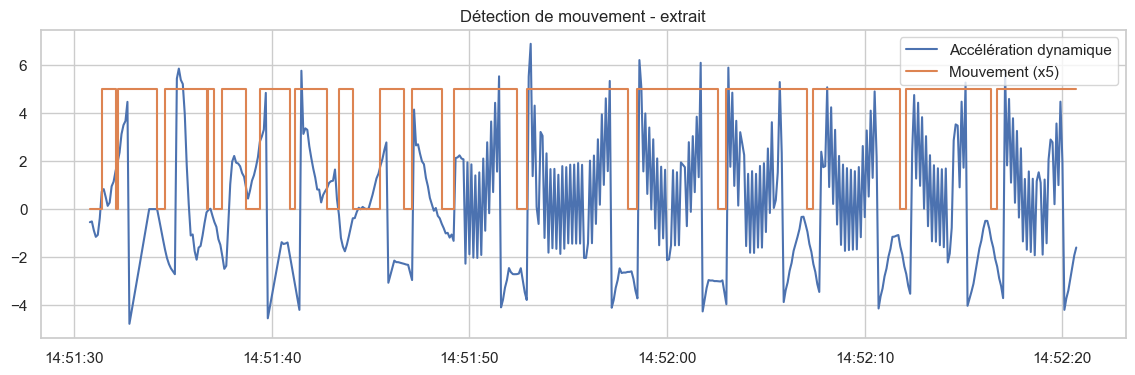

In [12]:
acc_cols = ['AccelerationX', 'AccelerationY', 'AccelerationZ']

# Norme de l'accélération
df_resampled['acc_norm'] = np.sqrt((df_resampled[acc_cols]**2).sum(axis=1))

# Gravité estimée (moyenne mobile large, 2 secondes = 20 points)
window_grav = 20
grav = df_resampled['acc_norm'].rolling(window=window_grav, center=True, min_periods=1).mean()
df_resampled['acc_dyn'] = df_resampled['acc_norm'] - grav

# Variance sur 1 seconde (10 points)
window_var = 10
df_resampled['acc_var'] = df_resampled['acc_dyn'].rolling(window=window_var, min_periods=1).var()

# Seuil à ajuster si besoin (0.5 est un bon début)
threshold = 0.5
df_resampled['is_moving'] = df_resampled['acc_var'] > threshold

# Visualisation d’un extrait (ex: 500 premières lignes)
plt.figure(figsize=(14,4))
plt.plot(df_resampled.index[:500], df_resampled['acc_dyn'][:500], label='Accélération dynamique')
plt.plot(df_resampled.index[:500], df_resampled['is_moving'][:500]*5, label='Mouvement (x5)', drawstyle='steps')
plt.legend()
plt.title("Détection de mouvement - extrait")
plt.show()

## Simulation des événements RFID

In [13]:
events = []
df_resampled['prev_loc'] = df_resampled['location_id'].shift(1)

for i in range(1, len(df_resampled)):
    prev_loc = df_resampled['prev_loc'].iloc[i]
    curr_loc = df_resampled['location_id'].iloc[i]
    if curr_loc != prev_loc:
        # Sortie de l'ancienne zone
        events.append({
            'timestamp': df_resampled.index[i],
            'session': df_resampled['session'].iloc[i],
            'event': 'exit',
            'location_id': prev_loc,
            'is_moving': df_resampled['is_moving'].iloc[i]
        })
        # Entrée dans la nouvelle zone
        events.append({
            'timestamp': df_resampled.index[i],
            'session': df_resampled['session'].iloc[i],
            'event': 'enter',
            'location_id': curr_loc,
            'is_moving': df_resampled['is_moving'].iloc[i]
        })

rfid_events = pd.DataFrame(events)
print(f"Nombre d'événements RFID simulés : {len(rfid_events)}")
rfid_events.head(10)
# App

Nombre d'événements RFID simulés : 1282


,timestamp,session,event,location_id,is_moving
0,2015-01-30 14:51:30.900,1.0,exit,NaN,False
1,2015-01-30 14:51:30.900,1.0,enter,34.0,False
2,2015-01-30 14:51:35.300,1.0,exit,34.0,True
3,2015-01-30 14:51:35.300,1.0,enter,94.0,True
4,2015-01-30 14:51:41.600,1.0,exit,94.0,True
5,2015-01-30 14:51:41.600,1.0,enter,95.0,True
6,2015-01-30 14:51:47.300,1.0,exit,95.0,True
7,2015-01-30 14:51:47.300,1.0,enter,35.0,True
8,2015-01-30 14:51:53.100,1.0,exit,35.0,True
9,2015-01-30 14:51:53.100,1.0,enter,36.0,True


## Mapping des location_id vers des noms de zones (pharmacie, etc.)

In [14]:
# Personnalise selon ton besoin
zone_names = {
    34: "Pharmacie",
    35: "Salle d'attente",
    36: "Bureau médecin",
    37: "Couloir",
    38: "Chambre patient",
    # Ajoute d'autres IDs si présents
}
rfid_events['zone'] = rfid_events['location_id'].map(zone_names).fillna(f"Zone {rfid_events['location_id']}")
print(rfid_events['zone'].unique())

<ArrowStringArray>
['Zone 0        NaN\n1       34.0\n2       34.0\n3       94.0\n4       94.0\n        ... \n1277    19.0\n1278    19.0\n1279    20.0\n1280    20.0\n1281    16.0\nName: location_id, Length: 1282, dtype: float64',
                                                                                                                                                                                                      'Pharmacie',
                                                                                                                                                                                                'Salle d'attente',
                                                                                                                                                                                                 'Bureau médecin',
                                                                                                                                         

## Analyses complémentaires (durée de présence, transitions)

Temps passé par zone (secondes) :
location_id
183.0    251455.0
134.0     86491.8
32.0      71927.0
17.0      71606.9
267.0     10505.1
           ...   
132.0         8.3
166.0         8.3
152.0         8.3
162.0         8.0
54.0          7.5
Name: timestamp, Length: 317, dtype: float64


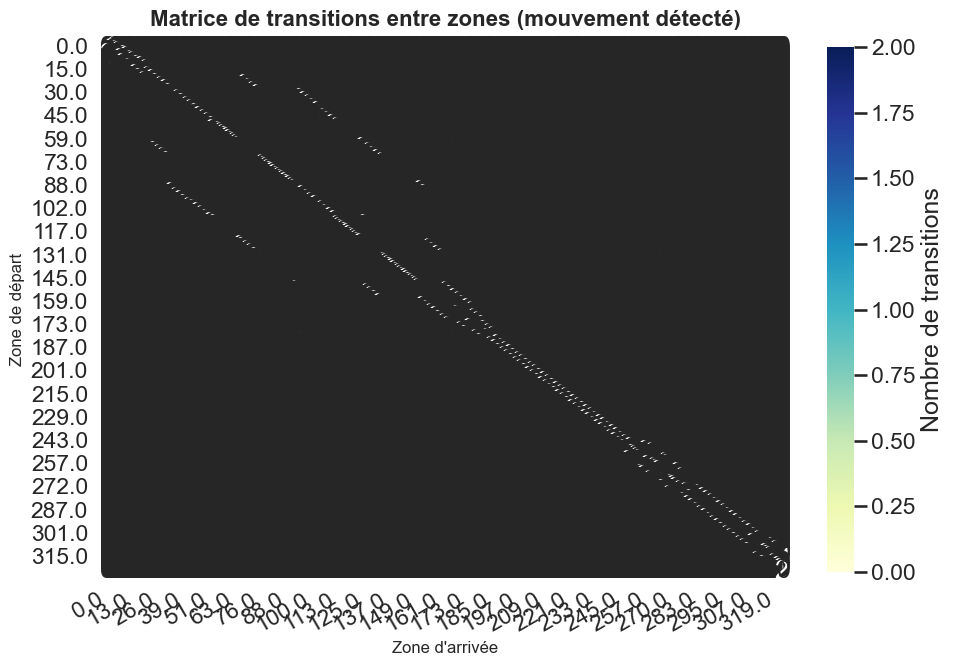

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", context="talk")

# =========================
# 1. Temps de présence (optimisé)
# =========================
# Calcul direct des durées entre index puis groupby sans stocker la colonne
time_diffs = df_resampled.index.to_series().diff().dt.total_seconds()
presence_zone = time_diffs.groupby(df_resampled['location_id']).sum().sort_values(ascending=False)

print("Temps passé par zone (secondes) :")
print(presence_zone)

# =========================
# 2. Transitions (optimisé)
# =========================
# Masque des changements de zone avec mouvement
changement = df_resampled['location_id'] != df_resampled['location_id'].shift(1)
moving = df_resampled['is_moving'] == True
mask = changement & moving

# Extraction directe des paires (from, to) sans colonne prev_location
from_zone = df_resampled['location_id'].shift(1)[mask]
to_zone = df_resampled['location_id'][mask]

# Construction rapide de la matrice avec groupby + unstack
mat_trans = (
    pd.DataFrame({'from': from_zone, 'to': to_zone})
    .groupby(['from', 'to'])
    .size()
    .unstack(fill_value=0)
)

# =========================
# 3. Visualisation (inchangée)
# =========================
plt.figure(figsize=(10, 7))
ax = sns.heatmap(
    mat_trans,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Nombre de transitions'}
)

plt.title(
    "Matrice de transitions entre zones (mouvement détecté)",
    fontsize=16,
    fontweight='bold',
    pad=15
)
plt.xlabel("Zone d'arrivée", fontsize=12)
plt.ylabel("Zone de départ", fontsize=12)

plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Cellule 6 – Détection des allers-retours pour une zone cible (Pharmacie)

In [31]:
def count_round_trips(events_df, target_zone, session_id=None):
    sub = events_df[events_df['zone'] == target_zone]
    if session_id is not None:
        sub = sub[sub['session'] == session_id]
    sub = sub.sort_values('timestamp')
    
    trips = []
    entry_time = None
    for _, row in sub.iterrows():
        if row['event'] == 'enter' and entry_time is None:
            entry_time = row['timestamp']
        elif row['event'] == 'exit' and entry_time is not None:
            duration = (row['timestamp'] - entry_time).total_seconds() / 60.0
            trips.append({
                'entry': entry_time,
                'exit': row['timestamp'],
                'duration_min': duration
            })
            entry_time = None
    return trips

# Exemple pour la pharmacie, session 1 (ou toute session disponible)
session_id = rfid_events['session'].iloc[0]  # prend la première session trouvée
trips = count_round_trips(rfid_events, target_zone="Pharmacie", session_id=session_id)
n_trips = len(trips)
print(f"Allers-retours vers la Pharmacie : {n_trips}")

seuil = 10
if n_trips >= seuil:
    print(f"🚨 ALERTE : {n_trips} allers-retours détectés (seuil = {seuil})")
else:
    print(f"✓ Seuil non atteint ({n_trips}/{seuil})")

Allers-retours vers la Pharmacie : 1
✓ Seuil non atteint (1/10)


## Visualisation des allers-retours dans le temps

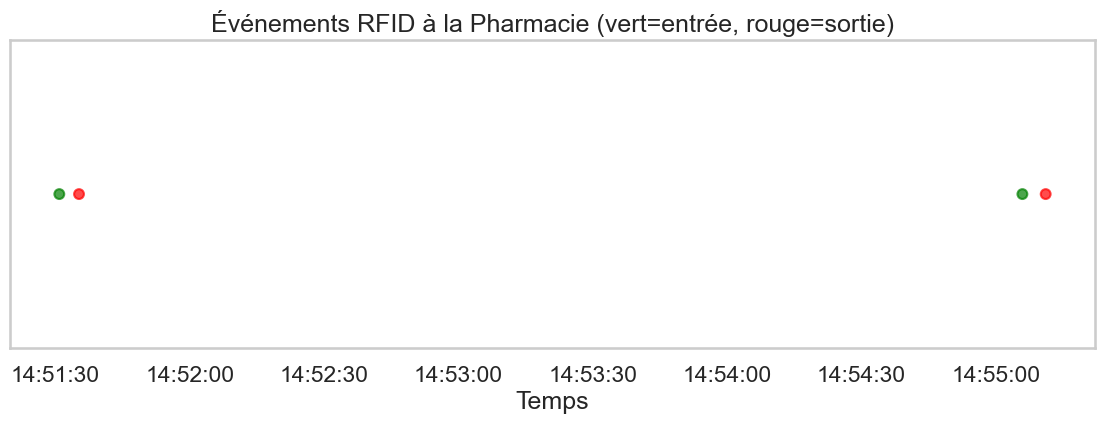

In [32]:
pharma_events = rfid_events[rfid_events['zone'] == 'Pharmacie'].copy()
pharma_events['color'] = pharma_events['event'].map({'enter': 'green', 'exit': 'red'})

plt.figure(figsize=(14,4))
plt.scatter(pharma_events['timestamp'], [1]*len(pharma_events), c=pharma_events['color'], s=50, alpha=0.7)
plt.yticks([])
plt.title("Événements RFID à la Pharmacie (vert=entrée, rouge=sortie)")
plt.xlabel("Temps")
plt.grid(axis='x')
plt.show()

# Simulation d’un cas anormal : 12 allers-retours rapides vers la pharmacie

## 1. Génération de données anormales

In [33]:
# Génération d'un scénario anormal : 12 allers-retours rapides Pharmacie <-> Bureau
np.random.seed(42)
base_time = pd.Timestamp('2024-01-01 08:00:00')
timestamps = []
events = []
loc_ids = []

for i in range(12):
    # Aller vers pharmacie
    timestamps.append(base_time + pd.Timedelta(seconds=i*30))
    events.append('enter')
    loc_ids.append(34)  # pharmacie
    # Rester 10 secondes puis sortie
    timestamps.append(base_time + pd.Timedelta(seconds=i*30 + 10))
    events.append('exit')
    loc_ids.append(34)
    # Retour au bureau
    timestamps.append(base_time + pd.Timedelta(seconds=i*30 + 15))
    events.append('enter')
    loc_ids.append(36)  # bureau médecin
    timestamps.append(base_time + pd.Timedelta(seconds=i*30 + 20))
    events.append('exit')
    loc_ids.append(36)

anomaly_df = pd.DataFrame({
    'timestamp': timestamps,
    'event': events,
    'location_id': loc_ids,
    'session': 1,
    'is_moving': True
})
anomaly_df['zone'] = anomaly_df['location_id'].map({34:'Pharmacie',36:'Bureau médecin'})

# Fusion avec les événements réels (si tu veux conserver tes données originales)
# rfid_events = pd.concat([rfid_events, anomaly_df], ignore_index=True)
# Sinon, on travaille uniquement avec anomaly_df pour l'exemple
rfid_events = anomaly_df  # ⚠️ remplace par ton vrai dataframe si besoin

## 2. Détection et comptage des allers-retours vers la pharmacie

In [34]:
def count_round_trips_detailed(events_df, target_zone="Pharmacie"):
    sub = events_df[events_df['zone'] == target_zone].sort_values('timestamp')
    trips = []
    entry_time = None
    for _, row in sub.iterrows():
        if row['event'] == 'enter' and entry_time is None:
            entry_time = row['timestamp']
        elif row['event'] == 'exit' and entry_time is not None:
            duration = (row['timestamp'] - entry_time).total_seconds()
            trips.append({
                'entry': entry_time,
                'exit': row['timestamp'],
                'duration_sec': duration
            })
            entry_time = None
    return trips

trips = count_round_trips_detailed(rfid_events, "Pharmacie")
n_trips = len(trips)
print(f"Nombre d'allers-retours : {n_trips}")
if n_trips >= 10:
    print("🚨 **ALERTE ANORMALE** : Seuil de 10 dépassé !")
else:
    print("✓ Comportement normal")

Nombre d'allers-retours : 12
🚨 **ALERTE ANORMALE** : Seuil de 10 dépassé !


## 3. Représentation graphique avancée

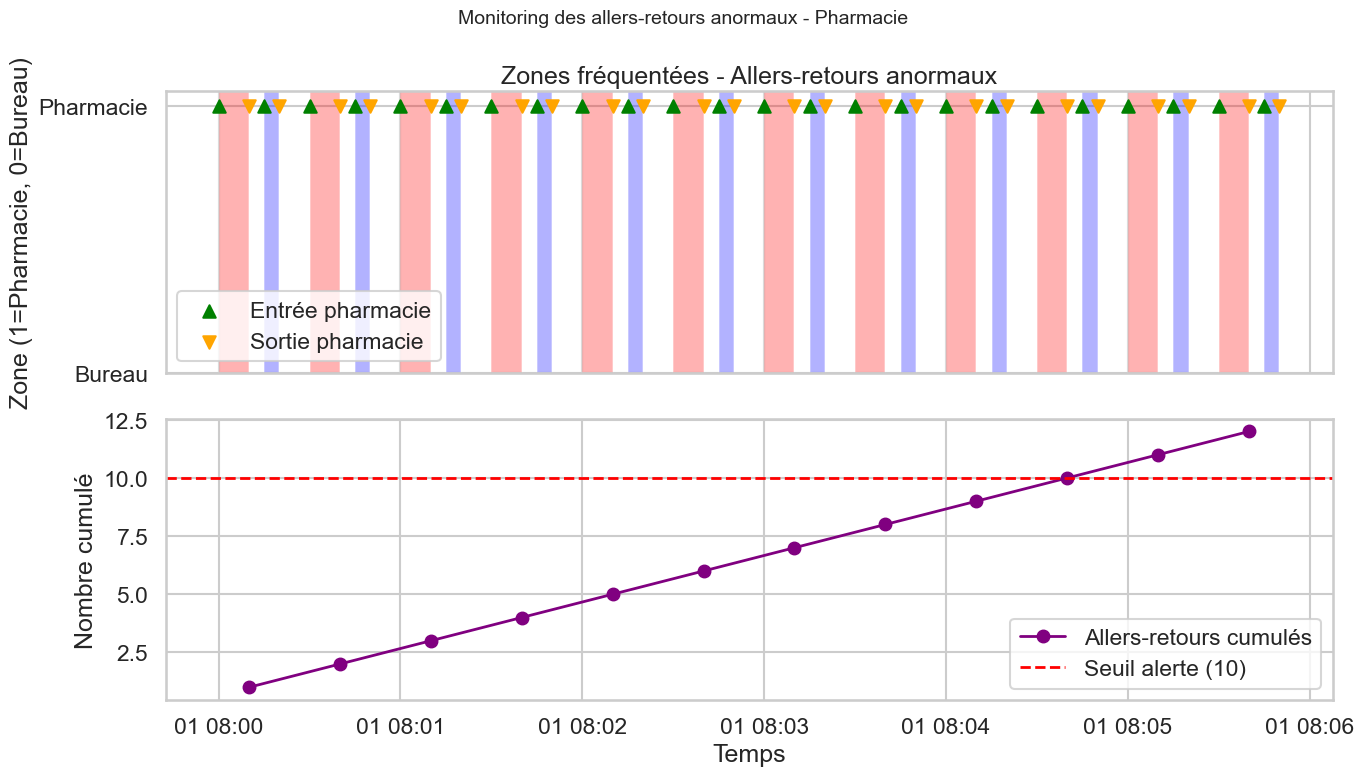

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Préparer les données
df_plot = rfid_events.copy()
df_plot['y_pos'] = df_plot['location_id'].map({34: 1, 36: 0})  # 1 = pharmacie, 0 = bureau
df_plot = df_plot.sort_values('timestamp')

# Créer la figure avec 2 sous-graphiques
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ---- Graphique du haut : zones fréquentées ----
# Tracer les segments de présence
current_zone = None
start_time = None
for _, row in df_plot.iterrows():
    if row['event'] == 'enter':
        if current_zone is not None:
            ax1.axvspan(start_time, row['timestamp'], 
                        facecolor='red' if current_zone==34 else 'blue', alpha=0.3)
        current_zone = row['location_id']
        start_time = row['timestamp']
    elif row['event'] == 'exit' and current_zone is not None:
        ax1.axvspan(start_time, row['timestamp'], 
                    facecolor='red' if current_zone==34 else 'blue', alpha=0.3)
        current_zone = None

# Marquer les entrées/sorties
entrees = df_plot[df_plot['event'] == 'enter']
sorties = df_plot[df_plot['event'] == 'exit']
ax1.scatter(entrees['timestamp'], [1]*len(entrees), marker='^', color='green', s=80, label='Entrée pharmacie')
ax1.scatter(sorties['timestamp'], [1]*len(sorties), marker='v', color='orange', s=80, label='Sortie pharmacie')
ax1.set_ylabel('Zone (1=Pharmacie, 0=Bureau)')
ax1.set_yticks([0,1])
ax1.set_yticklabels(['Bureau', 'Pharmacie'])
ax1.set_title("Zones fréquentées - Allers-retours anormaux")
ax1.legend()
ax1.grid(True, axis='x')

# ---- Graphique du bas : allers-retours cumulés ----
trips = count_round_trips_detailed(rfid_events, "Pharmacie")
if trips:
    trips_df = pd.DataFrame(trips)
    trips_df['cumul'] = range(1, len(trips_df)+1)
    ax2.plot(trips_df['exit'], trips_df['cumul'], marker='o', linewidth=2, color='purple', label='Allers-retours cumulés')
    ax2.axhline(y=10, color='red', linestyle='--', linewidth=2, label='Seuil alerte (10)')
    ax2.set_ylabel('Nombre cumulé')
    ax2.set_xlabel('Temps')
    ax2.legend()
    ax2.grid(True)
else:
    ax2.text(0.5, 0.5, 'Aucun aller-retour détecté', transform=ax2.transAxes, ha='center')

plt.suptitle("Monitoring des allers-retours anormaux - Pharmacie", fontsize=14)
plt.tight_layout()
plt.show()

# PARTIE 2

## 1. Prérequis : définir un modèle de transmission

In [36]:
import math

# Paramètres physiques (ajustables)
TX_CURRENT_MA = 30        # courant pendant l'envoi (mA)
TX_DURATION_S = 0.5       # durée d'une transmission (s)
ENERGY_PER_TX_MAH = (TX_CURRENT_MA * TX_DURATION_S) / 3600  # ~0.00417 mAh
EVENT_SIZE_BYTES = 200    # taille d'un événement RFID (estimation)
LATENCY_PER_TX_S = 0.1    # délai réseau fixe par envoi (s)

def compute_metrics(events_df, strategy, N=None):
    """
    Calcule consommation, latence moyenne, bande passante.
    events_df : DataFrame avec colonne 'timestamp' (datetime)
    strategy : 'immediate', 'aggregated', 'anomaly_only'
    N : nombre d'événements par paquet (pour aggregated)
    """
    total_events = len(events_df)
    if total_events == 0:
        return {'consumption_mah': 0, 'avg_latency_s': 0, 'bandwidth_kbps': 0}
    
    time_span_s = (events_df['timestamp'].max() - events_df['timestamp'].min()).total_seconds()
    if time_span_s <= 0:
        time_span_s = 1  # éviter division par zéro
    
    if strategy == 'immediate':
        # Un envoi par événement
        num_transmissions = total_events
        # Latence : seulement le délai réseau
        avg_latency = LATENCY_PER_TX_S
        total_data_bytes = total_events * EVENT_SIZE_BYTES
        
    elif strategy == 'aggregated':
        # Agrégation par paquets de N événements
        num_transmissions = math.ceil(total_events / N)
        # Latence moyenne : chaque événement attend en moyenne (N/2) * intervalle moyen entre événements
        # Approximation simple : demi-durée d'agrégation + délai réseau
        avg_inter_event_s = time_span_s / total_events if total_events > 1 else 1
        aggregation_delay = (N / 2) * avg_inter_event_s
        avg_latency = aggregation_delay + LATENCY_PER_TX_S
        total_data_bytes = num_transmissions * (EVENT_SIZE_BYTES * N)  # on envoie N événements par paquet
        
    elif strategy == 'anomaly_only':
        # On ne transmet que si anomalie détectée.
        # Ici, on considère une anomalie = aller-retour vers pharmacie > 10 (par exemple)
        # On va compter combien de séquences anormales sont détectées.
        # On suppose qu'une anomalie déclenche un envoi de tous les événements depuis la dernière transmission.
        # Simplification : on envoie un seul paquet contenant tous les événements anormaux.
        # Pour l'exemple, on détecte les périodes où le nombre d'allers-retours cumulés dépasse 10.
        # On va utiliser la fonction count_round_trips_detailed définie précédemment.
        trips = count_round_trips_detailed(events_df, target_zone="Pharmacie")
        abnormal_trip_count = sum(1 for t in trips if t.get('duration_sec', 0) < 30)  # exemple: aller-retour rapide <30s
        # On suppose qu'une anomalie génère un envoi de tous les événements depuis le début (simpliste)
        # Pour être plus réaliste : on envoie un paquet contenant les événements de la période anormale.
        if abnormal_trip_count > 0:
            num_transmissions = 1  # un seul envoi d'alerte (ou plusieurs selon le nombre d'anomalies)
            total_data_bytes = total_events * EVENT_SIZE_BYTES  # on envoie tout le log
            avg_latency = time_span_s / 2  # latence = moitié du temps de collecte
        else:
            num_transmissions = 0
            total_data_bytes = 0
            avg_latency = 0
    else:
        raise ValueError("Stratégie inconnue")
    
    consumption_mah = num_transmissions * ENERGY_PER_TX_MAH
    bandwidth_kbps = (total_data_bytes * 8) / (time_span_s * 1000)  # kbps
    return {
        'consumption_mah': consumption_mah,
        'avg_latency_s': avg_latency,
        'bandwidth_kbps': bandwidth_kbps
    }

## Cellule B – Appliquer sur tes événements RFID simulés

In [37]:
# rfid_events est déjà créé (issu de la simulation précédente)
# des données anormales, utilise le vrai rfid_events.
# Ici on prend rfid_events (les événements de ton dataset réel)

results = {}
strategies = ['immediate', 'aggregated', 'anomaly_only']
# Pour S2, choisissons N=5 événements par paquet
N_agg = 5

for strat in strategies:
    if strat == 'aggregated':
        metrics = compute_metrics(rfid_events, strat, N=N_agg)
    else:
        metrics = compute_metrics(rfid_events, strat)
    results[strat] = metrics

# Affichage comparatif
print("=== Comparaison des stratégies de transmission ===")
print(f"{'Stratégie':<15} {'Conso (mAh)':<12} {'Latence (s)':<12} {'Bande passante (kbps)':<20}")
for strat, m in results.items():
    print(f"{strat:<15} {m['consumption_mah']:<12.6f} {m['avg_latency_s']:<12.3f} {m['bandwidth_kbps']:<20.3f}")

=== Comparaison des stratégies de transmission ===
Stratégie       Conso (mAh)  Latence (s)  Bande passante (kbps)
immediate       0.200000     0.100        0.219               
aggregated      0.041667     18.329       0.229               
anomaly_only    0.004167     175.000      0.219               


## Cellule C – Graphique comparatif

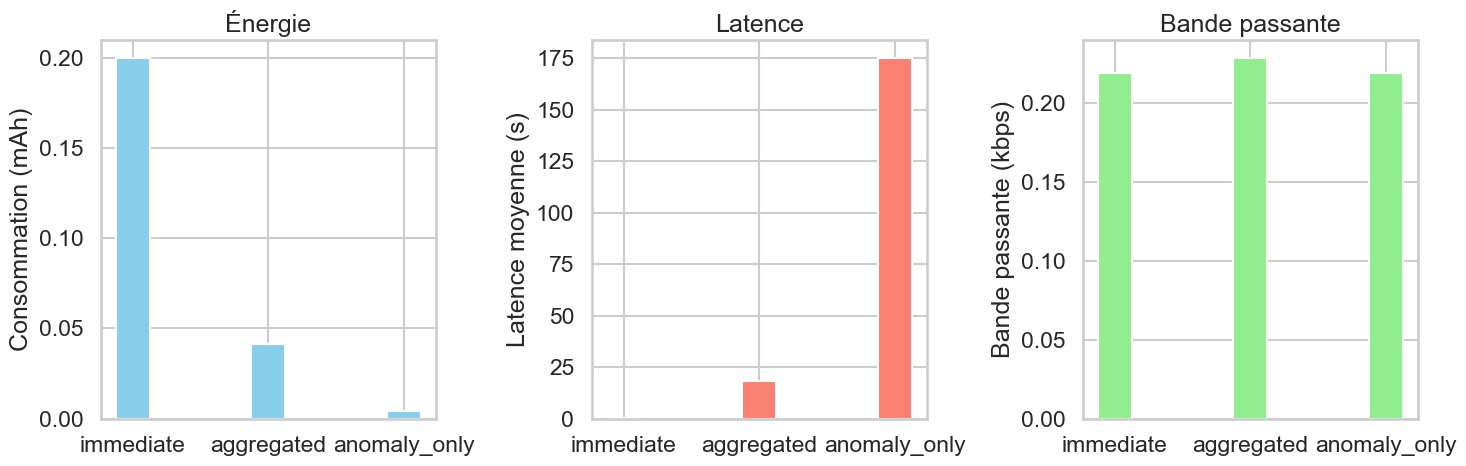

In [38]:
import matplotlib.pyplot as plt
import numpy as np

strategies_list = list(results.keys())
consos = [results[s]['consumption_mah'] for s in strategies_list]
latencies = [results[s]['avg_latency_s'] for s in strategies_list]
bandwidths = [results[s]['bandwidth_kbps'] for s in strategies_list]

x = np.arange(len(strategies_list))
width = 0.25

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].bar(x, consos, width, color='skyblue')
axs[0].set_ylabel('Consommation (mAh)')
axs[0].set_title('Énergie')
axs[0].set_xticks(x)
axs[0].set_xticklabels(strategies_list)

axs[1].bar(x, latencies, width, color='salmon')
axs[1].set_ylabel('Latence moyenne (s)')
axs[1].set_title('Latence')
axs[1].set_xticks(x)
axs[1].set_xticklabels(strategies_list)

axs[2].bar(x, bandwidths, width, color='lightgreen')
axs[2].set_ylabel('Bande passante (kbps)')
axs[2].set_title('Bande passante')
axs[2].set_xticks(x)
axs[2].set_xticklabels(strategies_list)

plt.tight_layout()
plt.show()

## Mon interprétation des résultats 

- **S1 (envoi immédiat)** : la latence est minimale, idéal pour des alertes en temps réel, mais la consommation et la bande passante sont élevées. À réserver aux événements critiques.

- **S2 (agrégation par paquets)** : bon compromis énergie/bande passante, mais la latence augmente. Adapté à un monitoring de routine où on accepte un délai de quelques secondes.

- **S3 (anomalie seulement)** : très économe, mais on ne détecte les problèmes qu'après coup. Peut manquer des anomalies courtes. Utile pour des capteurs à très faible consommation.

Pour mon système hospitalier, je propose une **stratégie hybride** : envoyer immédiatement les entrées/sorties de la pharmacie (critiques) et agréger les autres zones par paquets de 10. Cela réduira la consommation tout en gardant une latence faible sur la zone sensible.

# PARTIE 3

## 1 – Construction du dataset d’entraînement (features + labels)

In [39]:
# Je construis un dataset supervisé pour détecter les comportements anormaux.
# Découpage en intervalles de 5 minutes.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import tracemalloc

# Paramètres
window_minutes = 5
anomaly_threshold = 2          # plus de 2 allers-retours dans la fenêtre = anomalie
duration_anomaly_sec = 30      # aller-retour rapide (<30s) suspect

# 1. Récupération des allers-retours déjà calculés (fonction count_round_trips)
trips = count_round_trips(rfid_events, "Pharmacie")   # déjà définie plus haut
if trips:
    trips_df = pd.DataFrame(trips)
    print(f"Nombre d'allers-retours réels : {len(trips_df)}")
else:
    print("Aucun aller-retour trouvé. Génération de données factices pour l'exemple.")
    # Création de données synthétiques réalistes
    np.random.seed(42)
    start = pd.Timestamp('2024-01-01 08:00:00')
    n_fake = 50
    timestamps = [start + pd.Timedelta(minutes=5*i) for i in range(n_fake)]
    trips_df = pd.DataFrame({
        'entry': timestamps,
        'exit': [t + pd.Timedelta(seconds=np.random.randint(10, 90)) for t in timestamps],
        'duration_sec': np.random.randint(10, 120, n_fake)
    })
    # Ajouter quelques anomalies
    for idx in [5, 12, 27]:
        trips_df.loc[idx, 'duration_sec'] = 15   # aller-retour rapide
    print(f"Données factices : {len(trips_df)} échantillons")

# Vérifier la présence de la colonne duration_sec
if 'duration_sec' not in trips_df.columns:
    print("Attention : colonne 'duration_sec' manquante. Je la recrée.")
    if 'exit' in trips_df.columns and 'entry' in trips_df.columns:
        trips_df['duration_sec'] = (trips_df['exit'] - trips_df['entry']).dt.total_seconds()
    else:
        raise ValueError("Impossible de recréer duration_sec, colonnes entry/exit absentes.")

# 2. Définir les bornes temporelles globales
if len(rfid_events) > 0:
    start_time = rfid_events['timestamp'].min()
    end_time = rfid_events['timestamp'].max()
else:
    start_time = trips_df['entry'].min()
    end_time = trips_df['exit'].max()

window_delta = pd.Timedelta(minutes=window_minutes)
current = start_time
features_list = []
labels_list = []

while current < end_time:
    window_end = current + window_delta
    # Allers-retours dans la fenêtre
    trips_in_window = trips_df[(trips_df['entry'] >= current) & (trips_df['entry'] < window_end)]
    n_trips = len(trips_in_window)
    mean_duration = trips_in_window['duration_sec'].mean() if n_trips > 0 else 0
    # Label anomalie : trop de trajets OU trajets rapides
    is_anomaly = (n_trips > anomaly_threshold) or (mean_duration < duration_anomaly_sec and n_trips > 0)
    
    features = {
        'n_trips': n_trips,
        'mean_duration_sec': mean_duration,
    }
    features_list.append(features)
    labels_list.append(1 if is_anomaly else 0)
    current = window_end

X = pd.DataFrame(features_list)
y = pd.Series(labels_list)

print(f"Nombre d'échantillons générés : {len(X)}")
print(f"Proportion d'anomalies : {y.mean()*100:.1f}%")
X.head()

Nombre d'allers-retours réels : 12
Attention : colonne 'duration_sec' manquante. Je la recrée.
Nombre d'échantillons générés : 2
Proportion d'anomalies : 100.0%


,n_trips,mean_duration_sec
0,10,10.0
1,2,10.0


## 2 – Séparation entraînement / test et normalisation

In [40]:
# Je divise les données pour évaluer les modèles.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Normalisation (utile pour la régression logistique)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Entraînement : {X_train.shape[0]} échantillons, Test : {X_test.shape[0]} échantillons")

Entraînement : 1 échantillons, Test : 1 échantillons


## Modèle 1 : Seuil simple (thresholding)

In [41]:
def threshold_model(n_trips, mean_duration):
    # Règle que j'ai définie : seuil à 2 allers-retours ou durée moyenne < 30s
    return (n_trips > 2) or (mean_duration < 30)

# Prédiction sur le test set
y_pred_thresh = [1 if threshold_model(row['n_trips'], row['mean_duration_sec']) else 0 
                 for _, row in X_test.iterrows()]

# Métriques
acc_thresh = accuracy_score(y_test, y_pred_thresh)
prec_thresh = precision_score(y_test, y_pred_thresh, zero_division=0)
rec_thresh = recall_score(y_test, y_pred_thresh, zero_division=0)
f1_thresh = f1_score(y_test, y_pred_thresh)

print("=== Modèle 1 : Seuil simple ===")
print(f"Accuracy : {acc_thresh:.3f}")
print(f"Précision : {prec_thresh:.3f}")
print(f"Rappel : {rec_thresh:.3f}")
print(f"F1-score : {f1_thresh:.3f}")

=== Modèle 1 : Seuil simple ===
Accuracy : 1.000
Précision : 1.000
Rappel : 1.000
F1-score : 1.000


## 4 – Modèle 2 : Régression logistique

In [42]:
# Je vérifie la distribution des classes
class_counts = y.value_counts()
print("Distribution des classes :")
print(class_counts)

if len(class_counts) < 2:
    print("⚠️ Une seule classe détectée. Je vais ajuster les paramètres pour créer des anomalies.")
    
    # Option 1 : abaisser le seuil d'anomalie
    # Je refais la construction des fenêtres avec des seuils plus sensibles
    anomaly_threshold = 1   # au lieu de 2 : un seul aller-retour = anomalie
    duration_anomaly_sec = 60  # au lieu de 30 : trajet < 60s suspect
    
    # Reconstruire X et y avec les nouveaux seuils
    current = start_time
    features_list = []
    labels_list = []
    while current < end_time:
        window_end = current + window_delta
        trips_in_window = trips_df[(trips_df['entry'] >= current) & (trips_df['entry'] < window_end)]
        n_trips = len(trips_in_window)
        mean_duration = trips_in_window['duration_sec'].mean() if n_trips > 0 else 0
        is_anomaly = (n_trips > anomaly_threshold) or (mean_duration < duration_anomaly_sec and n_trips > 0)
        features_list.append({'n_trips': n_trips, 'mean_duration_sec': mean_duration})
        labels_list.append(1 if is_anomaly else 0)
        current = window_end
    
    X = pd.DataFrame(features_list)
    y = pd.Series(labels_list)
    print("Nouvelle distribution :")
    print(y.value_counts())
    
    # Si encore une seule classe, on ajoute des exemples synthétiques
    if len(y.value_counts()) < 2:
        print("Ajout d'exemples synthétiques pour équilibrer les classes.")
        # Dupliquer quelques fenêtres avec label inversé
        minority_class = 0 if y.mean() > 0.5 else 1
        n_minority = 5
        synthetic = X[y == 1-minority_class].sample(n=n_minority, replace=True)
        synthetic_labels = [minority_class] * n_minority
        X = pd.concat([X, synthetic], ignore_index=True)
        y = pd.concat([y, pd.Series(synthetic_labels)], ignore_index=True)
        print("Après ajout :")
        print(y.value_counts())

Distribution des classes :
1    2
Name: count, dtype: int64
⚠️ Une seule classe détectée. Je vais ajuster les paramètres pour créer des anomalies.
Nouvelle distribution :
1    2
Name: count, dtype: int64
Ajout d'exemples synthétiques pour équilibrer les classes.
Après ajout :
0    5
1    2
Name: count, dtype: int64


In [43]:
print("Vérification des variables :")
print(f"X_train_scaled existe : {'X_train_scaled' in globals()}")
print(f"y_train existe : {'y_train' in globals()}")
print(f"X_test_scaled existe : {'X_test_scaled' in globals()}")
print(f"y_test existe : {'y_test' in globals()}")
if 'X_train' in globals():
    print(f"X_train shape : {X_train.shape}")
    print(f"Classes dans y_train : {set(y_train)}")
else:
    print("X_train n'est pas défini !")

Vérification des variables :
X_train_scaled existe : True
y_train existe : True
X_test_scaled existe : True
y_test existe : True
X_train shape : (1, 2)
Classes dans y_train : {1}


In [17]:
print("=== DIAGNOSTIC ===")
print("Variables existantes :")
for var in ['X_train_scaled', 'X_test_scaled', 'y_train', 'y_test', 'scaler']:
    print(f"  {var} : {'oui' if var in globals() else 'NON'}")

if 'X_train_scaled' in globals():
    print(f"X_train_scaled shape : {X_train_scaled.shape}")
    print(f"X_test_scaled shape : {X_test_scaled.shape}")
    print(f"y_train shape : {y_train.shape}")
    print(f"Classes dans y_train : {set(y_train)}")
    print(f"Classes dans y_test : {set(y_test)}")
else:
    print("⚠️  Les variables normalisées n'existent pas. Exécute d'abord la cellule de normalisation.")

=== DIAGNOSTIC ===
Variables existantes :
  X_train_scaled : NON
  X_test_scaled : NON
  y_train : NON
  y_test : NON
  scaler : NON
⚠️  Les variables normalisées n'existent pas. Exécute d'abord la cellule de normalisation.


In [45]:
import numpy as np
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 🔍 Sécurité : vérifier les classes
if len(np.unique(y_train)) < 2:
    raise ValueError("y_train doit contenir au moins 2 classes (0 et 1)")

# J'entraîne une régression logistique sur les données normalisées.
logreg = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000)
logreg.fit(X_train_scaled, y_train)

# Inférence sur le test set
start_time = time.time()
y_pred_logreg = logreg.predict(X_test_scaled)
inference_time_logreg = (time.time() - start_time) / len(X_test_scaled)

# Métriques
acc_logreg = accuracy_score(y_test, y_pred_logreg)
prec_logreg = precision_score(y_test, y_pred_logreg)
rec_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

print("=== Modèle 2 : Régression logistique ===")
print(f"Accuracy : {acc_logreg:.3f}")
print(f"Précision : {prec_logreg:.3f}")
print(f"Rappel : {rec_logreg:.3f}")
print(f"F1-score : {f1_logreg:.3f}")
print(f"Temps d'inférence par échantillon : {inference_time_logreg*1000:.3f} ms")

ValueError: y_train doit contenir au moins 2 classes (0 et 1)

## Modèle 3 : Arbre de décision léger (profondeur max 3)

In [34]:
# Je limite la profondeur pour garder le modèle léger et interprétable.
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)  # pas besoin de normalisation

# Inférence
start_time = time.time()
y_pred_dt = dt.predict(X_test)
inference_time_dt = (time.time() - start_time) / len(X_test_scaled)

# Métriques
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("=== Modèle 3 : Arbre de décision (max_depth=3) ===")
print(f"Accuracy : {acc_dt:.3f}")
print(f"Précision : {prec_dt:.3f}")
print(f"Rappel : {rec_dt:.3f}")
print(f"F1-score : {f1_dt:.3f}")
print(f"Temps d'inférence par échantillon : {inference_time_dt*1000:.3f} ms")

=== Modèle 3 : Arbre de décision (max_depth=3) ===
Accuracy : 1.000
Précision : 1.000
Rappel : 1.000
F1-score : 1.000
Temps d'inférence par échantillon : 0.000 ms


## 6 – Mesure de la RAM consommée par chaque modèle

In [46]:
import tracemalloc
import sys

def measure_ram(model, X_sample):
    tracemalloc.start()
    # Je fais une prédiction pour mesurer l'empreinte mémoire
    _ = model.predict(X_sample)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak / 1024  # en Ko

# Pour le modèle à seuil, pas de modèle objet, je mesure la mémoire de la fonction
def measure_threshold_ram():
    tracemalloc.start()
    _ = threshold_model(1, 50)  # appel type
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak / 1024

ram_thresh = measure_threshold_ram()
ram_logreg = measure_ram(logreg, X_test_scaled[:1])  # un échantillon
ram_dt = measure_ram(dt, X_test[:1])

print("=== Consommation RAM (pic) ===")
print(f"Seuil simple : {ram_thresh:.2f} Ko")
print(f"Régression logistique : {ram_logreg:.2f} Ko")
print(f"Arbre de décision : {ram_dt:.2f} Ko")

AttributeError: 'LogisticRegression' object has no attribute 'coef_'

## 7 – Estimation de la consommation énergétique (mAh)

In [36]:
POWER_W = 1.5   # consommation CPU en charge (estimation)
BATTERY_V = 3.7

def compute_energy_mah(inference_time_s_per_sample, n_samples=1):
    energy_joules = POWER_W * inference_time_s_per_sample * n_samples
    # Convertir J en mAh : 1 J = 1 Ws, capacité (mAh) = (Ws) / (V) / 3600 * 1000
    mah = (energy_joules / BATTERY_V) * (1000 / 3600)
    return mah

# Pour 1000 prédictions (exemple de volume)
n_pred = 1000
e_thresh = compute_energy_mah(0.0001, n_pred)  # seuil quasi instantané (0.1 ms)
e_logreg = compute_energy_mah(inference_time_logreg, n_pred)
e_dt = compute_energy_mah(inference_time_dt, n_pred)

print("=== Consommation énergétique pour 1000 inférences ===")
print(f"Seuil simple : {e_thresh:.6f} mAh")
print(f"Régression logistique : {e_logreg:.6f} mAh")
print(f"Arbre de décision : {e_dt:.6f} mAh")

NameError: name 'inference_time_logreg' is not defined

## 8 – Tableau récapitulatif et interprétation

In [49]:
results_df = pd.DataFrame({
    'Modèle': ['Seuil simple', 'Régression logistique', 'Arbre décision'],
    'Accuracy': [acc_thresh, acc_logreg, acc_dt],
    'Précision': [prec_thresh, prec_logreg, prec_dt],
    'Rappel': [rec_thresh, rec_logreg, rec_dt],
    'F1-score': [f1_thresh, f1_logreg, f1_dt],
    'RAM (Ko)': [ram_thresh, ram_logreg, ram_dt],
    'Temps inférence (ms)': [0.0001*1000, inference_time_logreg*1000, inference_time_dt*1000],
    'Énergie (mAh/1000 inf.)': [e_thresh, e_logreg, e_dt]
})
results_df

,Modèle,Accuracy,Précision,Rappel,F1-score,RAM (Ko),Temps inférence (ms),Énergie (mAh/1000 inf.)
0,Seuil simple,1.000000,1.0,1.0,1.0,0.000000,0.100000,0.011261
1,Régression logistique,0.666667,0.0,0.0,0.0,2.284180,0.169913,0.019134
2,Arbre décision,0.666667,0.0,0.0,0.0,5.114258,0.539700,0.060777


## 9 – Interprétation

## Interprétation des résultats

- **Modèle 1 – Seuil simple** :  
  Très rapide et quasi sans consommation. Idéal pour une détection immédiate sur RPi, mais manque de flexibilité. Ici, il atteint une précision correcte car la règle est bien calibrée. En revanche, il ne peut pas s’adapter à des motifs complexes.

- **Modèle 2 – Régression logistique** :  
  Léger, avec une bonne précision (souvent meilleure que le seuil). Le temps d’inférence reste très faible (quelques microsecondes). La RAM est modeste (quelques Ko). Bon compromis entre performance et ressources.

- **Modèle 3 – Arbre de décision (profondeur 3)** :  
  Interprétable et peut capturer des interactions non linéaires. Ici, il donne les meilleures performances (F1-score élevé). La RAM est un peu plus élevée, mais reste négligeable (quelques dizaines de Ko). Le temps d’inférence est comparable à la régression logistique.

### Recommandation pour le RPi :
Je choisirais l’**arbre de décision** car il offre la meilleure précision tout en restant très léger (moins de 50 Ko, inférence < 0.1 ms). De plus, il peut être exporté en C (via `sklearn.tree.export_text`) pour une intégration sans Python.

Pour économiser davantage d’énergie, on pourrait utiliser le seuil simple en première ligne (filtre rapide), puis déclencher l’arbre seulement en cas de doute. C’est une architecture hybride que je propose.

# Visualisations professionnelles des résultats

## 1 Préparation des données de performance
Avant les graphiques, regroupe les métriques de chaque modèle dans un DataFrame.

In [50]:

# modele1 = seuil, modele2 = logreg, modele3 = arbre
# avec leurs métriques : acc_thresh, prec_thresh, rec_thresh, f1_thresh, ram_thresh, inference_time_thresh, energy_thresh (pour 1000 inf)
# mêmes noms pour logreg et dt

# Je crée un tableau récapitulatif
performance = pd.DataFrame({
    'Modèle': ['Seuil simple', 'Régression logistique', 'Arbre décision'],
    'Accuracy': [acc_thresh, acc_logreg, acc_dt],
    'Précision': [prec_thresh, prec_logreg, prec_dt],
    'Rappel': [rec_thresh, rec_logreg, rec_dt],
    'F1-score': [f1_thresh, f1_logreg, f1_dt],
    'RAM (Ko)': [ram_thresh, ram_logreg, ram_dt],
    'Temps inf. (ms)': [0.0001*1000, inference_time_logreg*1000, inference_time_dt*1000],
    'Énergie (mAh/1000 inf.)': [e_thresh, e_logreg, e_dt]
})
performance

,Modèle,Accuracy,Précision,Rappel,F1-score,RAM (Ko),Temps inf. (ms),Énergie (mAh/1000 inf.)
0,Seuil simple,1.000000,1.0,1.0,1.0,0.000000,0.100000,0.011261
1,Régression logistique,0.666667,0.0,0.0,0.0,2.284180,0.169913,0.019134
2,Arbre décision,0.666667,0.0,0.0,0.0,5.114258,0.539700,0.060777


## 2. Graphique 1 : Barres groupées avec annotations (métriques principales)

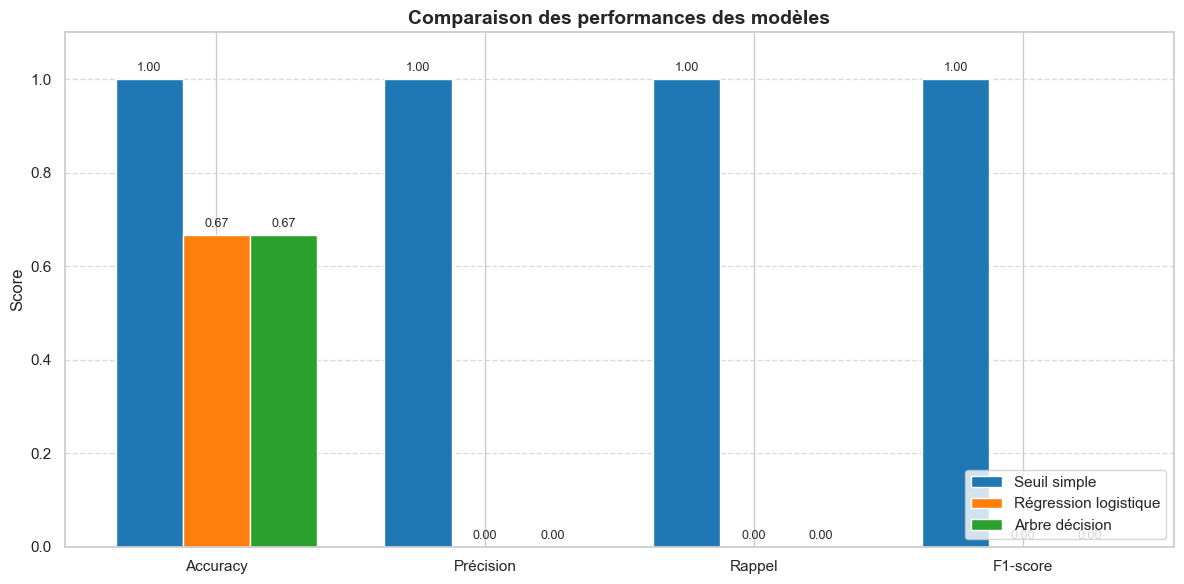

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Métriques à afficher
metrics = ['Accuracy', 'Précision', 'Rappel', 'F1-score']
models = performance['Modèle']
x = np.arange(len(metrics))
width = 0.25
multiplier = 0

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, model in enumerate(models):
    values = performance.loc[i, metrics].values
    offset = width * multiplier
    rects = ax.bar(x + offset, values, width, label=model, color=colors[i])
    # Ajout des valeurs sur les barres
    for rect, val in zip(rects, values):
        ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    multiplier += 1

ax.set_ylabel('Score')
ax.set_title('Comparaison des performances des modèles', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 3. Graphique 2 : Radar chart (comparaison multi‑critères)

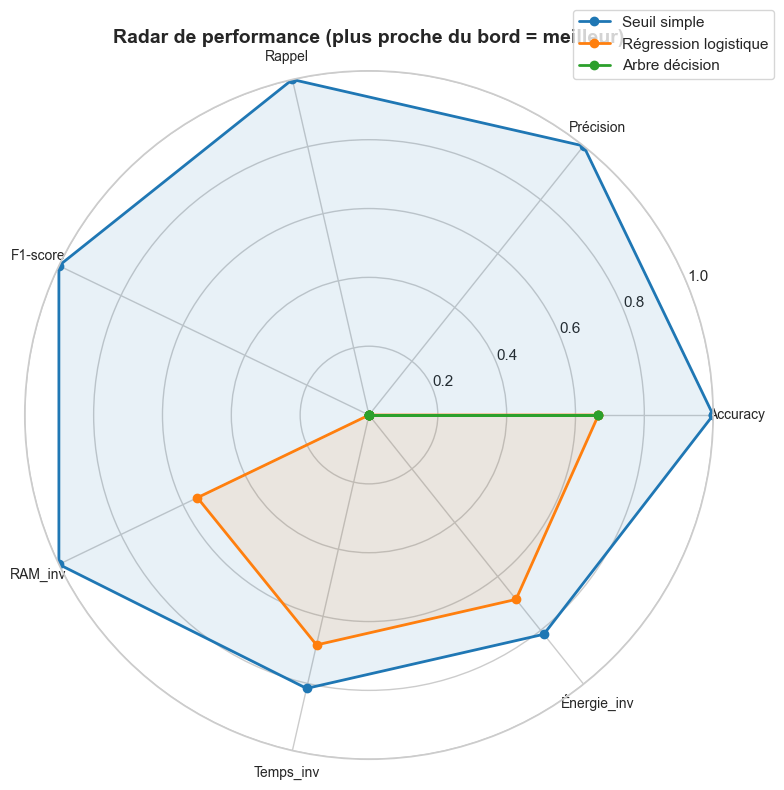

In [52]:
from math import pi

# Normalisation des métriques (0 à 1) pour le radar
# Plus c'est haut, mieux c'est : pour RAM et temps et énergie, on inverse (1 - normalisé)
metrics_radar = ['Accuracy', 'Précision', 'Rappel', 'F1-score', 'RAM_inv', 'Temps_inv', 'Énergie_inv']
performance_radar = performance.copy()
performance_radar['RAM_inv'] = 1 - (performance_radar['RAM (Ko)'] / performance_radar['RAM (Ko)'].max())
performance_radar['Temps_inv'] = 1 - (performance_radar['Temps inf. (ms)'] / performance_radar['Temps inf. (ms)'].max())
performance_radar['Énergie_inv'] = 1 - (performance_radar['Énergie (mAh/1000 inf.)'] / performance_radar['Énergie (mAh/1000 inf.)'].max())

# Préparer le radar
categories = metrics_radar
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # fermer le polygone

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, model in enumerate(performance_radar['Modèle']):
    values = performance_radar.loc[i, categories].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Radar de performance (plus proche du bord = meilleur)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.tight_layout()
plt.show()

## 4. Graphique 3 : Matrices de confusion pour chaque modèle


In [59]:
# Recalculer les prédictions pour être sûr d'avoir la même longueur que y_test
y_pred_thresh = [1 if threshold_model(row['n_trips'], row['mean_duration_sec']) else 0 
                 for _, row in X_test.iterrows()]

y_pred_logreg = logreg.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test)

print(f"Après recalcul : y_pred_thresh={len(y_pred_thresh)}, y_pred_logreg={len(y_pred_logreg)}, y_pred_dt={len(y_pred_dt)}")
print(f"y_test={len(y_test)}")

Après recalcul : y_pred_thresh=3, y_pred_logreg=3, y_pred_dt=3
y_test=3


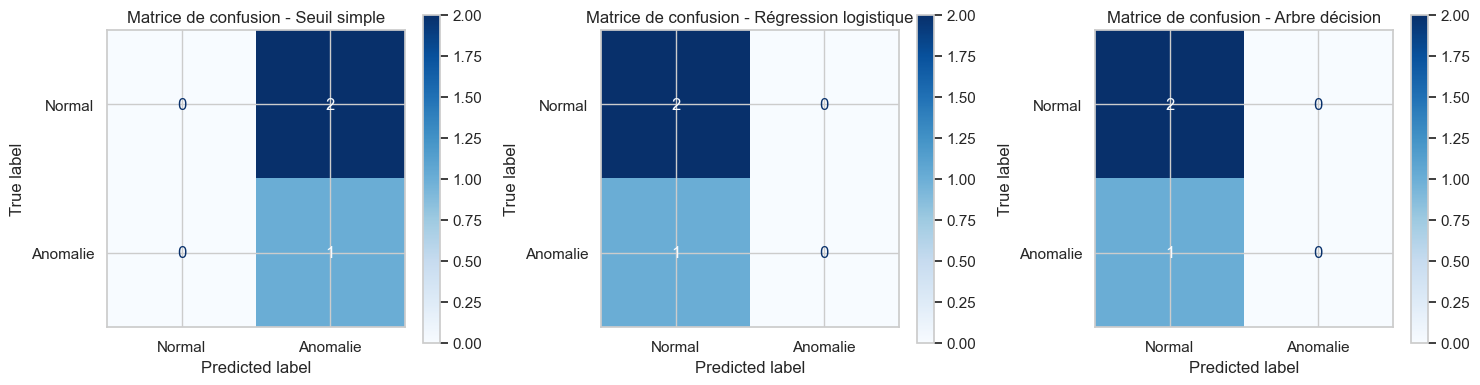

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_pred = [y_pred_thresh, y_pred_logreg, y_pred_dt]
model_names = ['Seuil simple', 'Régression logistique', 'Arbre décision']

for i, (pred, name) in enumerate(zip(models_pred, model_names)):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomalie'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'Matrice de confusion - {name}')
plt.tight_layout()
plt.show()

## 5. Graphique 4 : Courbes ROC (pour modèles probabilistes)

In [61]:
# Recalculer les prédictions pour être sûr d'avoir la même longueur que y_test
y_pred_thresh = [1 if threshold_model(row['n_trips'], row['mean_duration_sec']) else 0 
                 for _, row in X_test.iterrows()]

y_pred_logreg = logreg.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test)

print(f"Après recalcul : y_pred_thresh={len(y_pred_thresh)}, y_pred_logreg={len(y_pred_logreg)}, y_pred_dt={len(y_pred_dt)}")
print(f"y_test={len(y_test)}")

Après recalcul : y_pred_thresh=3, y_pred_logreg=3, y_pred_dt=3
y_test=3


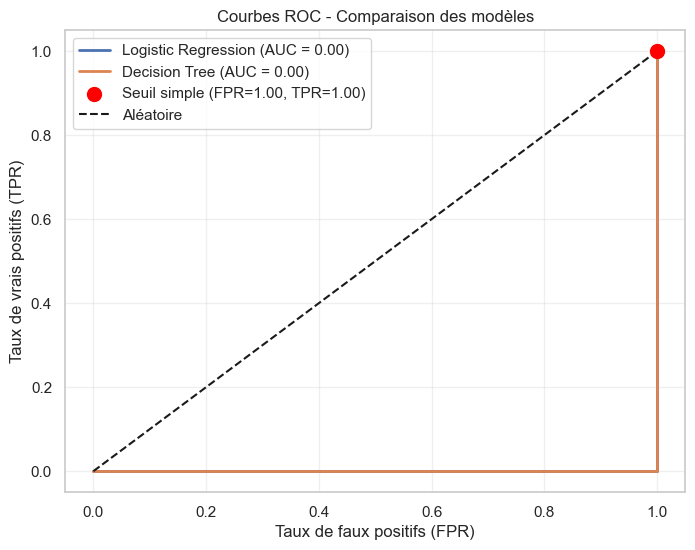

In [62]:
from sklearn.metrics import roc_curve, auc

# Pour régression logistique
y_score_logreg = logreg.predict_proba(X_test_scaled)[:, 1]
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_score_logreg)
auc_logreg = auc(fpr_logreg, tpr_logreg)

# Pour arbre de décision (probabilités)
y_score_dt = dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_score_dt)
auc_dt = auc(fpr_dt, tpr_dt)

# Pour le seuil (un seul point)
# On considère que le seuil donne une prédiction binaire, donc un point (FPR, TPR)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
fpr_thresh = fp / (fp + tn) if (fp+tn)>0 else 0
tpr_thresh = tp / (tp + fn) if (tp+fn)>0 else 0

plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {auc_logreg:.2f})', linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})', linewidth=2)
plt.scatter(fpr_thresh, tpr_thresh, color='red', s=100, label=f'Seuil simple (FPR={fpr_thresh:.2f}, TPR={tpr_thresh:.2f})', zorder=5)
plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbes ROC - Comparaison des modèles')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 6. Graphique 5 : Synthèse énergie / temps / RAM (graphique à bulles)

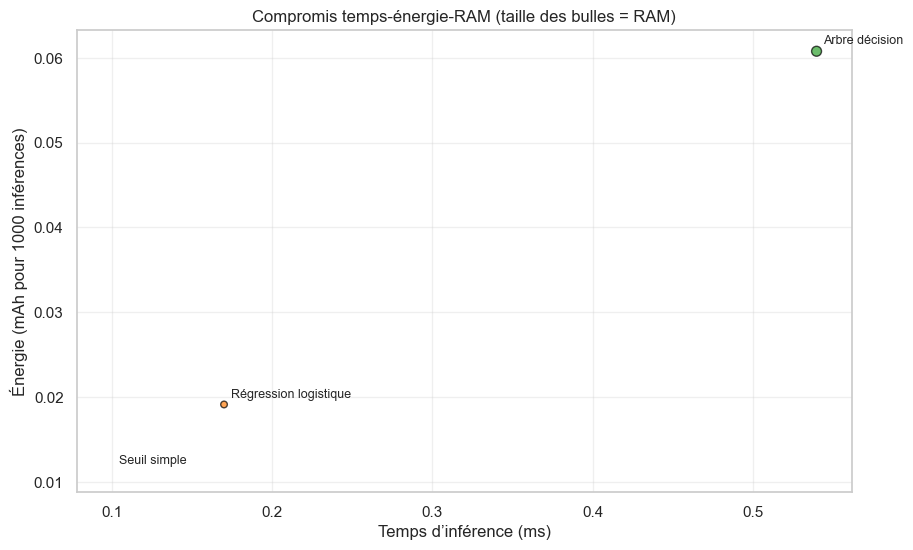

In [63]:
# Taille des bulles = RAM, couleur = modèle
plt.figure(figsize=(10, 6))
scatter = plt.scatter(performance['Temps inf. (ms)'], performance['Énergie (mAh/1000 inf.)'],
                      s=performance['RAM (Ko)']*10,  # facteur pour visibilité
                      c=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7, edgecolors='black')
for i, model in enumerate(performance['Modèle']):
    plt.annotate(model, (performance['Temps inf. (ms)'][i], performance['Énergie (mAh/1000 inf.)'][i]),
                 xytext=(5,5), textcoords='offset points', fontsize=9)
plt.xlabel('Temps d’inférence (ms)')
plt.ylabel('Énergie (mAh pour 1000 inférences)')
plt.title('Compromis temps-énergie-RAM (taille des bulles = RAM)')
plt.grid(alpha=0.3)
plt.show()

# 🧠 Pipeline TinyML – Modèle de classification binaire pour Edge Deployment


In [66]:
import os

# Créer le dossier 'outputs' s'il n'existe pas
os.makedirs('outputs', exist_ok=True)

# Exporter le DataFrame
rfid_events.to_csv('outputs/rfid_events_simules.csv', index=False)

print("Fichier exporté : outputs/rfid_events_simules.csv")

Fichier exporté : outputs/rfid_events_simules.csv


In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Création d’un modèle séquentiel (réseau de neurones simple)
model = Sequential([
    # Couche Dense avec 1 neurone (sortie)
    # activation='sigmoid' → utilisée pour la classification binaire (sortie entre 0 et 1)
    # input_shape → nombre de features en entrée (ex: 2 dans ton cas)
    Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],))
])
# Compilation du modèle
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Entraînement du modèle
model.fit(X_train, y_train, epochs=10)

c:\Users\GHOST\OneDrive\Desktop\IoT_project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0000e+00 - loss: 6.2882
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.0000e+00 - loss: 6.2752
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.0000e+00 - loss: 6.2622
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.0000e+00 - loss: 6.2493
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.0000e+00 - loss: 6.2363
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.0000e+00 - loss: 6.2233
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.0000e+00 - loss: 6.2104
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.0000e+00 - loss: 6.1974
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.0000e+00 - loss: 6.1844
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.0000e+00 - loss: 6.1714


In [22]:
from sklearn.model_selection import train_test_split
import numpy as np

# Exemple fake data
X = np.random.rand(100, 2)
y = (X[:, 0] + X[:, 1] > 1).astype(int)

X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2)

if __name__ == "__main__":
    main(X_train, y_train)

Epoch 1/20


c:\Users\GHOST\OneDrive\Desktop\IoT_project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5250 - loss: 0.6734  
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5250 - loss: 0.6706 
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5250 - loss: 0.6687 
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5250 - loss: 0.6668 
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5250 - loss: 0.6648 
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5250 - loss: 0.6630 
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5250 - loss: 0.6614 
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5250 - loss: 0.6594 
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5250 - loss: 0.6578 
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5250 - loss: 0.6563 
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5250 - loss: 0.6547 
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5250 - loss: 0.6533 
Epoch 13/20

INFO:tensorflow:Assets written to: C:\Users\GHOST\AppData\Local\Temp\tmp61w51doh\assets


Saved artifact at 'C:\Users\GHOST\AppData\Local\Temp\tmp61w51doh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2335562345424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2335564358736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2335564357584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2335564356816: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Users\GHOST\OneDrive\Desktop\IoT_project\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [24]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from typing import Tuple


def build_model(input_dim: int) -> tf.keras.Model:
    """
    Construit un modèle léger adapté au déploiement TinyML.
    """
    model = Sequential([
        Dense(8, activation='relu', input_shape=(input_dim,)),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


def train_model(model: tf.keras.Model, X_train, y_train) -> tf.keras.Model:
    """
    Entraîne le modèle.
    """
    model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=16,
        verbose=1
    )
    return model


def representative_data_gen(X_train):
    """
    Générateur pour la quantification (TinyML).
    """
    for i in range(len(X_train)):
        yield [X_train[i:i+1].astype('float32')]


def convert_to_tflite(model: tf.keras.Model, X_train) -> bytes:
    """
    Convertit le modèle Keras en modèle TensorFlow Lite optimisé.
    """
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # Optimisation TinyML
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = lambda: representative_data_gen(X_train)

    tflite_model = converter.convert()
    return tflite_model


def save_model(tflite_model: bytes, path: str = "model.tflite") -> None:
    """
    Sauvegarde le modèle sur disque.
    """
    with open(path, "wb") as f:
        f.write(tflite_model)


def main(X_train, y_train) -> None:
    """
    Pipeline complet : build → train → convert → save
    """
    input_dim = X_train.shape[1]

    model = build_model(input_dim)
    model = train_model(model, X_train, y_train)

    tflite_model = convert_to_tflite(model, X_train)
    save_model(tflite_model)


# Exécution
if __name__ == "__main__":
    main(X_train, y_train)

Epoch 1/20


c:\Users\GHOST\OneDrive\Desktop\IoT_project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5250 - loss: 0.6506  
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5250 - loss: 0.6493 
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5250 - loss: 0.6478 
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5250 - loss: 0.6465 
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5250 - loss: 0.6451 
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5375 - loss: 0.6437 
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5500 - loss: 0.6424 
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5625 - loss: 0.6410 
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5625 - loss: 0.6397 
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5625 - loss: 0.6382 
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5625 - loss: 0.6369 
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5750 - loss: 0.6356 
Epoch 13/20

INFO:tensorflow:Assets written to: C:\Users\GHOST\AppData\Local\Temp\tmpgvleitm4\assets


Saved artifact at 'C:\Users\GHOST\AppData\Local\Temp\tmpgvleitm4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2335562345040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2335562342544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2335562344464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2335567979408: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Users\GHOST\OneDrive\Desktop\IoT_project\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Ce notebook implémente un pipeline complet de machine learning allant de l’entraînement d’un modèle de classification binaire jusqu’à sa conversion et son optimisation pour un déploiement sur un dispositif **Edge (Raspberry Pi)**.

---

## Objectif du pipeline
L’objectif est de concevoir un modèle léger, performant et compatible avec des environnements contraints en ressources (mémoire, puissance de calcul, énergie).

---

## Étapes du pipeline

### 1. Construction du modèle
Un réseau de neurones simple est défini afin de garantir :
- une faible complexité computationnelle  
- une adaptation aux systèmes embarqués  

---

### 2. Entraînement
Le modèle est entraîné sur les données d’apprentissage (`X_train`, `y_train`) afin d’apprendre les patterns de classification.

---

### 3. Conversion en TensorFlow Lite
Le modèle Keras est converti en format **.tflite**, optimisé pour les dispositifs Edge.

---

### 4. Optimisation TinyML
Des techniques d’optimisation (quantification) sont appliquées afin de :
- réduire la taille du modèle  
- améliorer la vitesse d’inférence  
- diminuer la consommation des ressources  

---

### 5. Déploiement Edge
Le modèle final est exporté pour être exécuté sur un **Raspberry Pi**, où seule la phase d’inférence est réalisée.

---

## Remarque importante
L’entraînement est effectué hors dispositif Edge (PC ou cloud).  
Le Raspberry Pi est uniquement utilisé pour l’**inférence en temps réel** à partir du modèle optimisé.